In [1]:
import uproot #读取ROOT文件数据。
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt

topPMTs = np.arange(28, dtype=int)       #定义了一个整数数组变量topPMTs，通过np.arange函数生成了一个范围从0到63的数组，用于存储顶部PMT的编号
botPMTs = np.arange(28, 56, dtype=int)  #定义了一个整数数组变量botPMTs，通过np.arange函数生成了一个范围从64到127的数组，用于存储底部PMT的编号

In [2]:
with uproot.open(f"/home/leiyang/TPC_DE_SIm-test/data/S210w.root") as file:
#with uproot.open(f"{file_prefix2}/gate2_pit6.root") as file:
    pmtNumber = file['mcTree']['pmtNumber'].array(library='np') #从ROOT文件的mcTree中提取pmtNumber数据，并将其存储在名为pmtNumber的NumPy数组中
    nsciillation = file['mcTree']['nPrimaries'].array(library='np') #从ROOT文件的mcTree中提取nsciillation数据，并将其存储在名为nsciillation的NumPy数组中
    mask = nsciillation > 0 
    n_filtered = np.sum(mask)  # 筛选后的总事件数（例如82,014）
    primaryX = file['mcTree']['primaryX'].array(library='np')
    primaryY = file['mcTree']['primaryY'].array(library='np')
    primaryZ = file['mcTree']['primaryZ'].array(library='np')

    # 提取每个事件的第一个粒子坐标
    primaryX_scalar = np.array([x[0] if len(x) > 0 else np.nan for x in primaryX])
    primaryY_scalar = np.array([x[0] if len(x) > 0 else np.nan for x in primaryY])
    primaryZ_scalar = np.array([x[0] if len(x) > 0 else np.nan for x in primaryZ])
    # 初始化结构化数组时直接基于筛选后的长度
    dtype = [
        ('nsci', int),
        ('nHits', int),
        ('topNHits', int),
        ('botNHits', int),
        ('primaryX', float),
        ('primaryY', float),
        ('primaryZ', float)
    ]
    LCE_info = np.zeros(n_filtered, dtype=dtype)  # 使用正确长度初始化
    pmtNumber_filtered = pmtNumber[mask]
    print(len(pmtNumber_filtered))
    nsciillation_filtered = nsciillation[mask]
    for index, (pmtHits, scintHits) in enumerate(zip(pmtNumber_filtered, nsciillation_filtered)): #遍历pmtNumber数组，并使用enumerate函数获取索引和对应的值pmtHits。
        LCE_info[index]['nsci'] = scintHits
        LCE_info[index]['nHits'] = pmtHits.size  #将pmtHits数组的大小存储在LCE_info数组的相应位置，表示对应运行和事件的击中数量。
        ignited_PMTs = np.unique(pmtHits)  #获取pmtHits数组中唯一的PMT值，并存储在ignited_PMTs数组中。
        # Light Leak?
        LCE_info[index]['topNHits'] = np.count_nonzero(np.in1d(pmtHits, topPMTs)) #将与顶部PMT相关的击中数量存储在LCE_info数组的相应位置。
        LCE_info[index]['botNHits'] = np.count_nonzero(np.in1d(pmtHits, botPMTs))
    LCE_info['primaryX'] = primaryX_scalar[mask]
    LCE_info['primaryY'] = primaryY_scalar[mask]
    LCE_info['primaryZ'] = primaryZ_scalar[mask]


100000


In [3]:

nPEs         = LCE_info['nHits']
nsci = LCE_info['nsci']
primaryX = LCE_info['primaryX']                  #从LCE_info数组中提取名为primaryX的字段数据，并将其存储在名为primaryX的变量中

primaryY = LCE_info['primaryY']
primaryZ = LCE_info['primaryZ']
nHitsTop = LCE_info['topNHits']
nHitsBot = LCE_info['botNHits']
print(primaryX,primaryY,primaryZ)
S2_LCE = nPEs/nsci
print(nPEs, nsci)
S2_AVG_LCE = np.nanmean(S2_LCE)
S2_topLCE = nHitsTop/nsci
S2_AVG_topLCE = np.nanmean(S2_topLCE)
S2_botLCE = nHitsBot/nsci
S2_AVG_botLCE = np.nanmean(S2_botLCE)
S2_AFT = np.nanmean(S2_topLCE/S2_LCE)
print(S2_AVG_topLCE,S2_AVG_botLCE, S2_AVG_LCE, S2_AFT)

[-58.40249785  31.89366907 -44.92183022 ...  61.80249785  14.47081439
 -22.56958849] [ 31.38325  -3.50555  26.31095 ... -11.75225 -44.03545 -41.17595] [67.601 67.601 67.601 ... 67.601 67.601 67.601]
[811 934 854 ... 851 953 895] [1807 1822 1777 ... 1823 1849 1819]
0.23499921706151644 0.24891288216770238 0.48391209922921874 0.48520449037153435


In [4]:
pmtHits

array([51, 30, 49, 10,  5, 51, 29, 21, 13, 12, 29,  8, 13, 55, 21, 30, 13,
       27, 39, 25, 38, 41,  1, 12, 21, 14, 12, 44, 21, 14, 33,  4, 49, 21,
       14, 39, 13, 54, 13, 38, 26, 28, 28, 43, 51,  5,  8, 34, 53, 50, 32,
       47, 19, 19, 44,  1, 12, 25, 44, 19, 36, 30, 26, 26,  3, 12, 52, 43,
       13, 13, 53, 20,  2, 41, 22, 36, 12, 42, 19, 51, 21, 42,  4, 19, 12,
       19, 32, 39, 43, 12, 35, 38, 13, 48, 41, 24,  2, 13, 52, 12,  6, 13,
        3, 39, 43, 20,  9,  6, 39, 43, 52, 36, 34, 46, 51, 44, 30, 37, 55,
       30, 52, 52, 13, 31, 50, 29, 36, 33,  2, 43, 30, 12, 34, 32,  5, 35,
       43, 12, 20, 28, 13, 13, 48, 40, 35,  6, 44, 13, 19, 20, 38, 45, 13,
       21, 50,  6, 21, 40, 50, 14, 50, 41, 14, 52,  7, 21, 12, 20,  6, 40,
       14,  5, 27,  5, 31, 34, 51, 19, 28, 34, 23,  4, 39, 16,  9,  1, 20,
       46,  5,  4,  4, 36, 12, 40, 29,  7, 48, 26, 33, 29, 33,  5, 30, 27,
       13, 27, 19, 11, 20, 33, 36, 26, 13, 35, 42, 49, 20, 12, 12, 13, 14,
       54, 52, 25, 25, 25

--- 拟合结果 ---
幅度 (A):     830.40 ± 2.63
位置 (xi):    0.245926 ± 0.000110
尺度 (omega): 0.024748 ± 0.000091
形状 (alpha): -2.0342 ± 0.0244


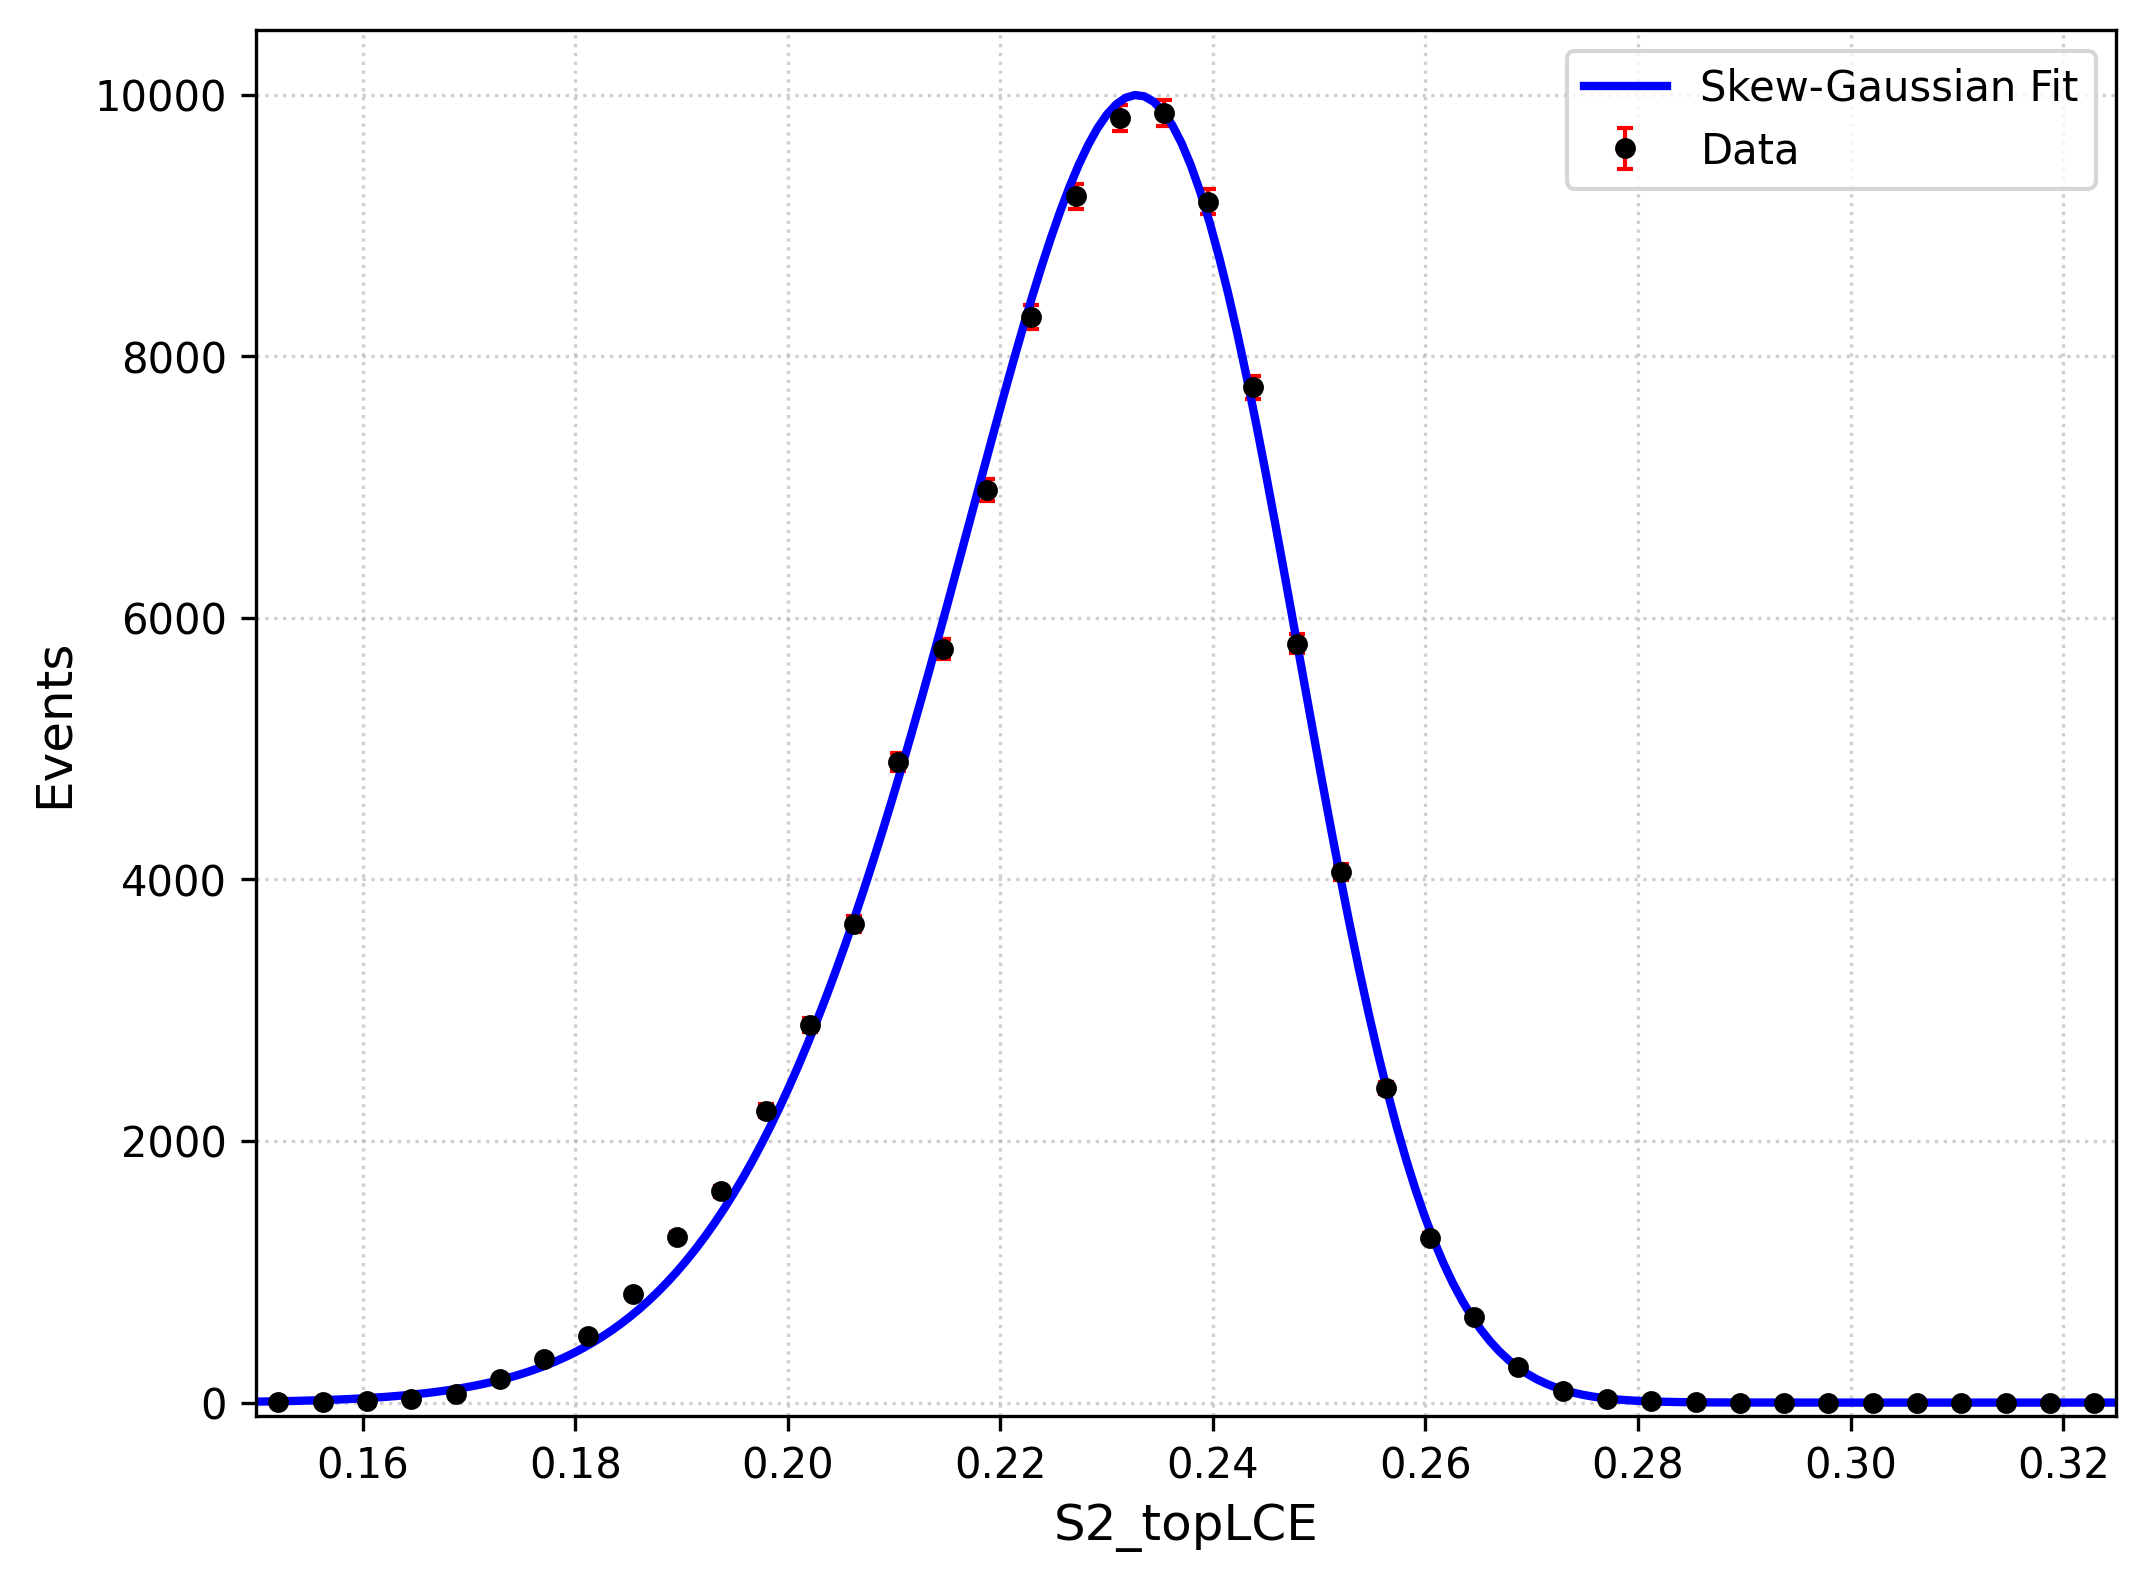

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm

# ==========================================
# 1. 数据准备
# ==========================================
S2_topLCE = nHitsTop / nsci-0.007
clean_data = S2_topLCE[np.isfinite(S2_topLCE)]

bins = 42
# 建议手动指定 range 以确保拟合区间稳定
hist_range = (0.15, 0.325)
counts, bin_edges = np.histogram(clean_data, bins=bins, range=hist_range)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)
# 避免除以 0 (如果某 bin 计数为 0，给它一个极小的误差或者忽略)
errors[errors == 0] = 1 

# ==========================================
# 2. 定义斜高斯模型函数
# x: 自变量
# A: 幅度 (Amplitude)
# xi: 位置参数 (Location, 类似均值但不完全等于)
# omega: 尺度参数 (Scale, 类似标准差)
# alpha: 形状参数 (Skewness, 0则退化为普通高斯, >0右偏, <0左偏)
# ==========================================
def skew_gaussian(x, A, xi, omega, alpha):
    # 使用 scipy.stats.norm 提高计算稳定性
    return A * norm.pdf(x, xi, omega) * norm.cdf(alpha * (x - xi) / omega)

# ==========================================
# 3. 执行拟合
# ==========================================
# 设置初始猜测值 [A, xi, omega, alpha]
initial_guess = [np.max(counts)*0.01, np.mean(clean_data), np.std(clean_data), -2]

# p_opt: 最优参数; p_cov: 协方差矩阵
p_opt, p_cov = curve_fit(skew_gaussian, bin_centers, counts, 
                         p0=initial_guess, sigma=errors, absolute_sigma=True)

# 计算参数的误差 (协方差矩阵对角线的平方根)
p_err = np.sqrt(np.diag(p_cov))

# 提取结果
A_fit, xi_fit, omega_fit, alpha_fit = p_opt
A_err, xi_err, omega_err, alpha_err = p_err

print("--- 拟合结果 ---")
print(f"幅度 (A):     {A_fit:.2f} ± {A_err:.2f}")
print(f"位置 (xi):    {xi_fit:.6f} ± {xi_err:.6f}")
print(f"尺度 (omega): {omega_fit:.6f} ± {omega_err:.6f}")
print(f"形状 (alpha): {alpha_fit:.4f} ± {alpha_err:.4f}")

# ==========================================
# 4. 绘图
# ==========================================
plt.figure(figsize=(8, 6), dpi=300)

# 绘制原始数据误差棒
plt.errorbar(bin_centers, counts, yerr=errors, fmt='o', 
             markersize=4, color='black', ecolor='red', 
             capsize=2, elinewidth=1, label='Data')

# 绘制拟合曲线
x_smooth = np.linspace(0.15, 0.325, 200)
y_fit = skew_gaussian(x_smooth, *p_opt)
plt.plot(x_smooth, y_fit, color='blue', linewidth=2, 
         label=f'Skew-Gaussian Fit')

# 图形修饰
plt.xlabel('S2_topLCE', fontsize=12)
plt.ylabel('Events', fontsize=12)
plt.xlim(0.15, 0.325)
plt.ylim(bottom=-100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [6]:
LCE_value = []
for index, (pmtHits, scintHits) in tqdm(enumerate(zip(pmtNumber_filtered, nsciillation_filtered))):
    LCE_value_list = np.empty(56)
    pmtNumberlist = pmtNumber[index]
    for i in range(56):
        LCE_value_list[i] = np.sum(([pmtNumberlist==i]))
    LCE_value.append(LCE_value_list/scintHits)

100000it [00:37, 2688.07it/s]


In [7]:
LCE_value = np.array(LCE_value)

In [8]:
LCE_value.shape

(100000, 56)

In [9]:
LCE_value_dtype = [
    ('LCE_value', object),   # 第一列：56元素数组
    ('x', np.float64), # 第二列：浮点数值
    ('y', np.float64)    # 第三列：整数值
]

LCE_value_array = np.empty(len(LCE_value),dtype=LCE_value_dtype)
for i in range(len(LCE_value_array)):
    LCE_value_array['LCE_value'][i] = LCE_value[i]
LCE_value_array['x'] = primaryX
LCE_value_array['y'] = primaryY


In [21]:
np.mean(np.sum(LCE_value,axis=1))

0.48391209922921874

/tmp/ipykernel_2118794/1929977437.py:4: RuntimeWarning: invalid value encountered in divide
  H_LCE_TPC = N_2_TPC / N_1_TPC


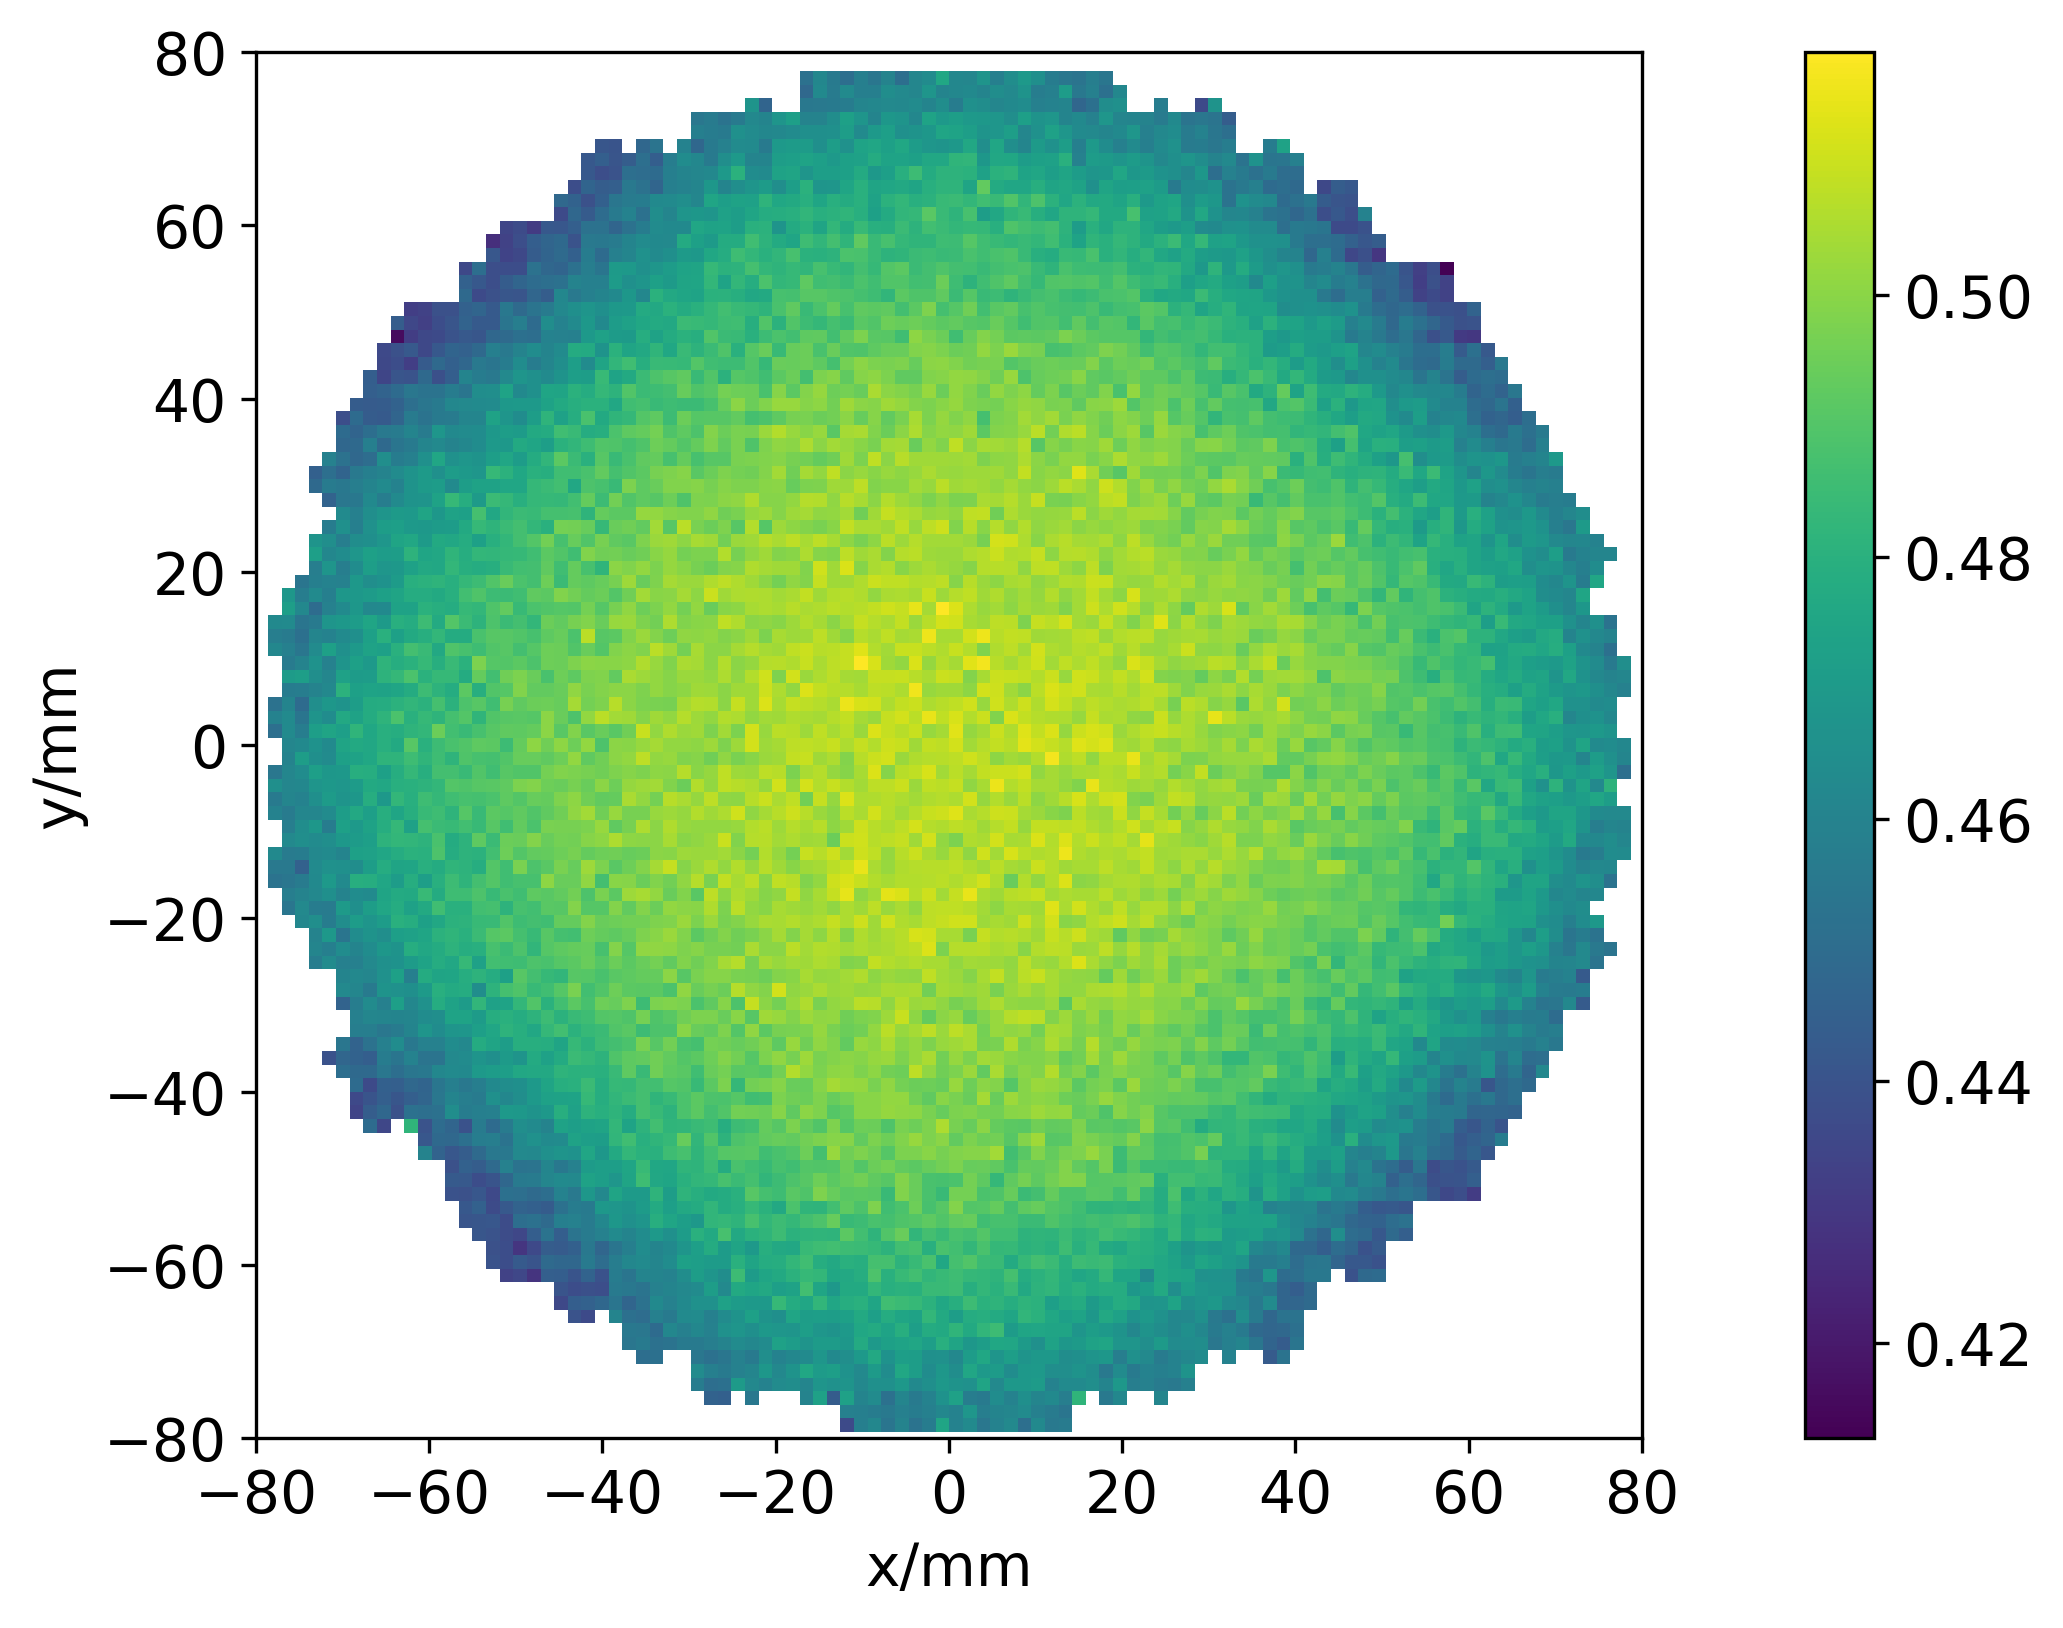

In [34]:

# fig, axs = plt.subplots(1, 2, tight_layout=True)
N_1_TPC, bins_x_TPC, bins_y_TPC = np.histogram2d(primaryX, primaryY, bins=100)
N_2_TPC, bins_x_TPC, bins_y_TPC = np.histogram2d(primaryX, primaryY, bins=100, weights=np.sum(LCE_value, axis=1))
H_LCE_TPC = N_2_TPC / N_1_TPC

# 创建图形
fig, ax = plt.subplots(figsize=(14, 6),dpi =300)  # 创建单个子图
fig.set_facecolor('white')

# 绘制图像
image_TPC = ax.imshow(H_LCE_TPC.T, origin='lower', extent=(bins_x_TPC[0], bins_x_TPC[-1], bins_y_TPC[0], bins_y_TPC[-1]))
cbar = plt.colorbar(image_TPC, ax=ax)
cbar.ax.tick_params(labelsize=14)  # Adjust the size of the colorbar ticks
plt.xticks(fontsize=14)  # 横轴刻度
plt.yticks(fontsize=14)  # 纵轴刻度
plt.xlim(-80,80)
plt.ylim(-80,80)
# 设置标题和标签
ax.set_xlabel('x/mm',fontsize=14)
ax.set_ylabel('y/mm',fontsize=14)

# 显示图形
plt.show()


In [36]:
import numpy as np



# ===================== 2. 拆分原始数据 =====================
# 提取56维数值：shape=(100000, 56)
pmt_values = np.vstack([item[0] for item in LCE_value_array])
# 提取x/y坐标：shape=(100000,)
x_coords = np.array([item[1] for item in LCE_value_array])
y_coords = np.array([item[2] for item in LCE_value_array])

# 打印验证拆分结果
print("56维数值形状:", pmt_values.shape)  # 应输出 (100000, 56)
print("x坐标形状:", x_coords.shape)       # 应输出 (100000,)
print("y坐标形状:", y_coords.shape)       # 应输出 (100000,)

# ===================== 3. 坐标分箱（划分为300×300网格） =====================
grid_size = 100  # 网格大小

# 计算x/y坐标的最小值和最大值（自动适配你的数据范围）
x_min, x_max = x_coords.min(), x_coords.max()
y_min, y_max = y_coords.min(), y_coords.max()

# 生成300个均匀分箱的边界（共grid_size+1个边界点）
x_bins = np.linspace(x_min, x_max, grid_size + 1)
y_bins = np.linspace(y_min, y_max, grid_size + 1)

# 给每个数据点分配网格索引（0~299）
x_indices = np.digitize(x_coords, x_bins) - 1  # 减1让索引从0开始
y_indices = np.digitize(y_coords, y_bins) - 1

# 处理边界：确保索引不超出0~299（避免最大值点被分到300）
x_indices = np.clip(x_indices, 0, grid_size - 1)
y_indices = np.clip(y_indices, 0, grid_size - 1)

# ===================== 4. 计算每个网格内的56维均值 =====================
# 初始化结果数组：(56, 300, 300)，初始值为nan（无数据的网格保留nan）
result = np.full((56, grid_size, grid_size), np.nan, dtype=np.float64)

# 遍历每个网格，计算均值
for i in range(grid_size):
    for j in range(grid_size):
        # 找到当前网格内的所有数据点索引
        mask = (x_indices == i) & (y_indices == j)
        # 如果该网格有数据，计算56维均值
        if np.any(mask):
            grid_data = pmt_values[mask]  # shape=(n, 56)，n为网格内点数
            mean_vals = grid_data.mean(axis=0)  # shape=(56,)，按行求均值
            result[:, i, j] = mean_vals  # 赋值到结果数组


result = np.nan_to_num(result, nan=0.0)

# ===================== 5. 验证最终结果 =====================
print("最终三维数组形状:", result.shape)  # 应输出 (56, 300, 300)

# 示例：打印第0个PMT在(100, 100)网格的均值
print("第0个PMT在(100,100)网格的均值:", result[0, 0, 0])
# 统计有数据的网格数量（非nan）
valid_grids = np.sum(~np.isnan(result[0]))
print(f"有数据的网格数量: {valid_grids}/{grid_size*grid_size}")


56维数值形状: (100000, 56)
x坐标形状: (100000,)
y坐标形状: (100000,)
最终三维数组形状: (56, 100, 100)
第0个PMT在(100,100)网格的均值: 0.0
有数据的网格数量: 10000/10000


In [37]:
mask = ~np.isnan(result[0])
mask[0]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [42]:
x_value = 0.5*(x_bins[1:]+x_bins[:-1])
y_value = 0.5*(y_bins[1:]+y_bins[:-1])
x_value.shape

(100,)

In [30]:
np.sum(LCE_value, axis=1)

array([0.44881018, 0.51262349, 0.48058526, ..., 0.46681295, 0.51541374,
       0.49202859])

In [38]:
result.shape

(56, 100, 100)

In [39]:
np.mean(np.sum(result,axis=0))*4/np.pi

0.4804460947188123

In [43]:
LCE_value_array
np.save('/home/leiyang/TPC_DE_SIm-test/LCE_info/LCE_value.npy',result,allow_pickle=True)
np.save('/home/leiyang/TPC_DE_SIm-test/LCE_info/LCE_xs.npy',x_value,allow_pickle=True)
np.save('/home/leiyang/TPC_DE_SIm-test/LCE_info/LCE_ys.npy',y_value,allow_pickle=True)

In [20]:
len(np.unique(primaryX))

7967

In [21]:
print(np.max(LCE_value_array['x']),np.min(LCE_value_array['x']))

78.6634590008085 -78.6634590008085
